# Pertemuan 1: Exploratory Data Analysis (EDA)
Tahap ini bertujuan untuk memahami karakteristik dataset sebelum diproses. 
Kita juga akan membuktikan mengapa beberapa tindakan *preprocessing* perlu dilakukan.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 1. Load Dataset
df = pd.read_csv('Sales - Marketing customer dataset.csv')

# 2. Tampilkan Info dan Statistik Deskriptif
print("=== 5 Baris Pertama ===")
display(df.head())

print("\n=== Informasi Dataset ===")
df.info()

print("\n=== Statistik Deskriptif ===")
display(df.describe())

=== 5 Baris Pertama ===


,customer_id,gender,age,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,...,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
0,10001,Male,52.0,India,Berlin,2022-05-10 00:00:00,2024-12-31 00:00:00,Email,Tablet,Annual,...,0,0,3,UPI,3.0,10,27.56,915.310827,14,0
1,10002,NaN,35.0,Germany,Mumbai,2024-06-16 00:00:00,2024-05-07 00:00:00,Organic,Desktop,Monthly,...,5,0,3,BKash,3.0,7,15.15,2079.960938,11,0
2,10003,Female,27.0,Germany,London,2023-08-23 00:00:00,2024-04-28 00:00:00,Email,Mobile,Annual,...,1,0,2,UPI,5.0,6,13.51,1379.150885,9,0
3,10004,Female,36.0,India,Mumbai,2024-01-28 00:00:00,2023-05-20 00:00:00,Facebook Ads,Tablet,Annual,...,0,0,2,PayPal,4.0,6,25.65,774.652684,7,0
4,10005,Male,29.0,USA,Hamburg,2023-07-21 00:00:00,2024-04-07 00:00:00,Referral,Mobile,Monthly,...,2,1,4,BKash,3.0,1,12.39,87.680409,11,0



=== Informasi Dataset ===
<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 15000 non-null  int64  
 1   gender                      14262 non-null  str    
 2   age                         13800 non-null  float64
 3   country                     15000 non-null  str    
 4   city                        15000 non-null  str    
 5   signup_date                 15000 non-null  str    
 6   last_purchase_date          15000 non-null  str    
 7   acquisition_channel         15000 non-null  str    
 8   device_type                 15000 non-null  str    
 9   subscription_type           15000 non-null  str    
 10  is_premium_user             15000 non-null  int64  
 11  total_visits                15000 non-null  int64  
 12  avg_session_time            15000 non-null  float64
 13  pages_per_sessi

,customer_id,age,is_premium_user,total_visits,avg_session_time,pages_per_session,email_open_rate,email_click_rate,total_spent,avg_order_value,discount_used,support_tickets,refund_requested,delivery_delay_days,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
count,15000.000000,13800.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,13950.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,14298.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,17500.500000,35.203913,0.304467,15.000933,8.020805,4.002901,0.496278,0.251231,524.357397,60.080882,0.494467,1.995600,0.147667,2.981333,3.588754,4.968667,17.575238,1235.698200,6.975133,0.153200
std,4330.271354,10.334384,0.460197,3.892704,2.991499,1.479846,0.290108,0.144689,467.050070,24.746203,0.499986,1.421214,0.354781,1.720537,1.088703,3.155495,7.183437,657.521849,4.323443,0.360192
min,10001.000000,-4.000000,0.000000,3.000000,0.006095,0.007845,0.000000,0.000000,0.267291,0.071596,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,5.000000,0.368886,0.000000,0.000000
25%,13750.750000,28.000000,0.000000,12.000000,5.974555,2.989150,0.240000,0.130000,300.432074,43.032470,0.000000,1.000000,0.000000,2.000000,3.000000,2.000000,11.380000,741.301251,3.000000,0.000000
50%,17500.500000,35.000000,0.000000,15.000000,7.991907,3.996992,0.500000,0.250000,498.843859,60.108827,0.000000,2.000000,0.000000,3.000000,4.000000,5.000000,17.630000,1216.210685,7.000000,0.000000
75%,21250.250000,42.000000,1.000000,18.000000,10.059986,5.014406,0.750000,0.380000,702.396635,76.888445,1.000000,3.000000,0.000000,4.000000,4.000000,8.000000,23.770000,1677.860399,11.000000,0.000000
max,25000.000000,95.000000,1.000000,31.000000,19.123716,10.843172,1.000000,0.500000,15910.431879,154.554696,1.000000,9.000000,1.000000,11.000000,5.000000,10.000000,30.000000,3767.490455,14.000000,1.000000



Jumlah baris duplikat di dataset: 0
Baris duplikat ini akan kita hapus di tahap Preprocessing agar tidak menyesatkan model.

Umur terendah sebelum preprocessing: -4.0


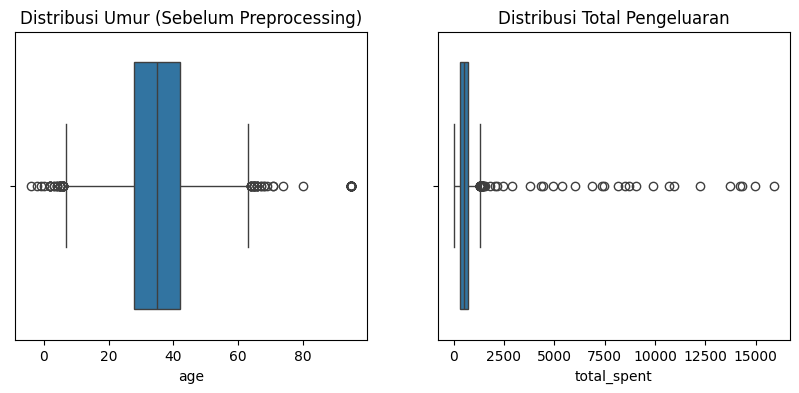

Terdapat umur dengan nilai negatif yang merupakan outlier (kesalahan data). Nanti akan kita ubah menjadi nilai Median.
Alasan menggunakan Median daripada Mean: Median lebih kebal (robust) terhadap tarikan nilai ekstrim/outlier dibandingkan Mean.


In [2]:
# 3. Pengecekan Duplikat
print(f"\nJumlah baris duplikat di dataset: {df.duplicated().sum()}")
print("Baris duplikat ini akan kita hapus di tahap Preprocessing agar tidak menyesatkan model.")

# 4. Deteksi Outlier (Umur & Total Pengeluaran)
print(f"\nUmur terendah sebelum preprocessing: {df['age'].min()}")
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.boxplot(x=df['age'])
plt.title('Distribusi Umur (Sebelum Preprocessing)')

plt.subplot(1, 2, 2)
sns.boxplot(x=df['total_spent'])
plt.title('Distribusi Total Pengeluaran')
plt.show()

print("Terdapat umur dengan nilai negatif yang merupakan outlier (kesalahan data). Nanti akan kita ubah menjadi nilai Median.")
print("Alasan menggunakan Median daripada Mean: Median lebih kebal (robust) terhadap tarikan nilai ekstrim/outlier dibandingkan Mean.")

In [3]:
# 5. Analisis Missing Value & Fitur Irrelevan
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_df = missing_percentage[missing_percentage > 0].sort_values(ascending=False)

print("\n=== Persentase Missing Values per Kolom (%) ===")
print(missing_df)

print("\n=== ALASAN PEMBUANGAN FITUR ===")
print("1. coupon_code: Persentase missing valuenya hampir 41%. Terlalu banyak data yang hilang, jika diimputasi akan merusak distribusi asli dan menyebabkan bias. Fitur ini akan dihapus.")
print("2. customer_id: Merupakan identifier unik tiap baris. Tidak memiliki pola prediktif dan bisa menyebabkan model overfit/menghafal ID.")
print("3. signup_date & last_purchase_date: Berupa data format tanggal murni. Algoritma dasar tidak bisa mencerna teks tanggal secara langsung. Selain itu, tanggal terakhir pembelian bisa menjadi 'Data Leakage' (memberi tahu model secara curang siapa yang churn). Fitur ini akan dibuang.")

# Visualisasi Diagram Batang untuk Missing Value
plt.figure(figsize=(10, 5))
sns.barplot(x=missing_df.index, y=missing_df.values, palette='Reds_r')
plt.title('Persentase Missing Value per Kolom')
plt.ylabel('Persentase (%)')
plt.xlabel('Kolom')
plt.xticks(rotation=45)
plt.show()



=== Persentase Missing Values per Kolom (%) ===
coupon_code           40.886667
age                    8.000000
total_spent            7.000000
gender                 4.920000
satisfaction_score     4.680000
dtype: float64

=== ALASAN PEMBUANGAN FITUR ===
1. coupon_code: Persentase missing valuenya hampir 41%. Terlalu banyak data yang hilang, jika diimputasi akan merusak distribusi asli dan menyebabkan bias. Fitur ini akan dihapus.
2. customer_id: Merupakan identifier unik tiap baris. Tidak memiliki pola prediktif dan bisa menyebabkan model overfit/menghafal ID.
3. signup_date & last_purchase_date: Berupa data format tanggal murni. Algoritma dasar tidak bisa mencerna teks tanggal secara langsung. Selain itu, tanggal terakhir pembelian bisa menjadi 'Data Leakage' (memberi tahu model secara curang siapa yang churn). Fitur ini akan dibuang.



=== Visualisasi Keseimbangan Kelas Target (Churn) ===


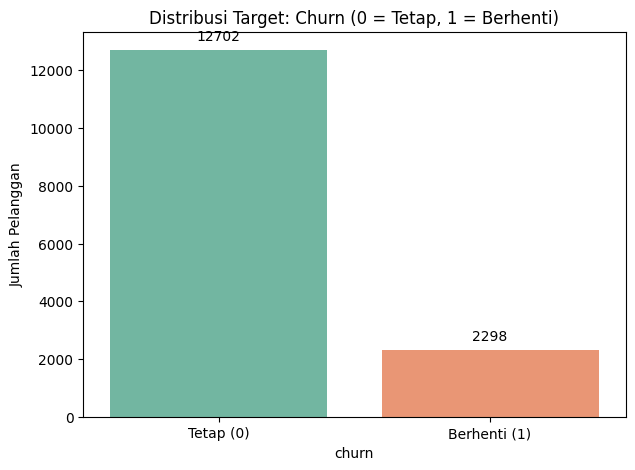

Data terlihat IMBALANCED (Tidak seimbang). Jumlah pelanggan yang tetap jauh lebih banyak daripada yang churn. Oleh karena itu, kita butuh SMOTE di tahap Validasi.


In [4]:
# 6. Visualisasi Target Keseimbangan Kelas Churn
print("\n=== Visualisasi Keseimbangan Kelas Target (Churn) ===")
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df, x='churn', palette='Set2')
plt.title('Distribusi Target: Churn (0 = Tetap, 1 = Berhenti)')
plt.ylabel('Jumlah Pelanggan')
ax.set_xticklabels(['Tetap (0)', 'Berhenti (1)'])
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10, xytext=(0, 5), textcoords='offset points')
plt.show()

print("Data terlihat IMBALANCED (Tidak seimbang). Jumlah pelanggan yang tetap jauh lebih banyak daripada yang churn. Oleh karena itu, kita butuh SMOTE di tahap Validasi.")


=== Heatmap Korelasi Fitur Numerik ===


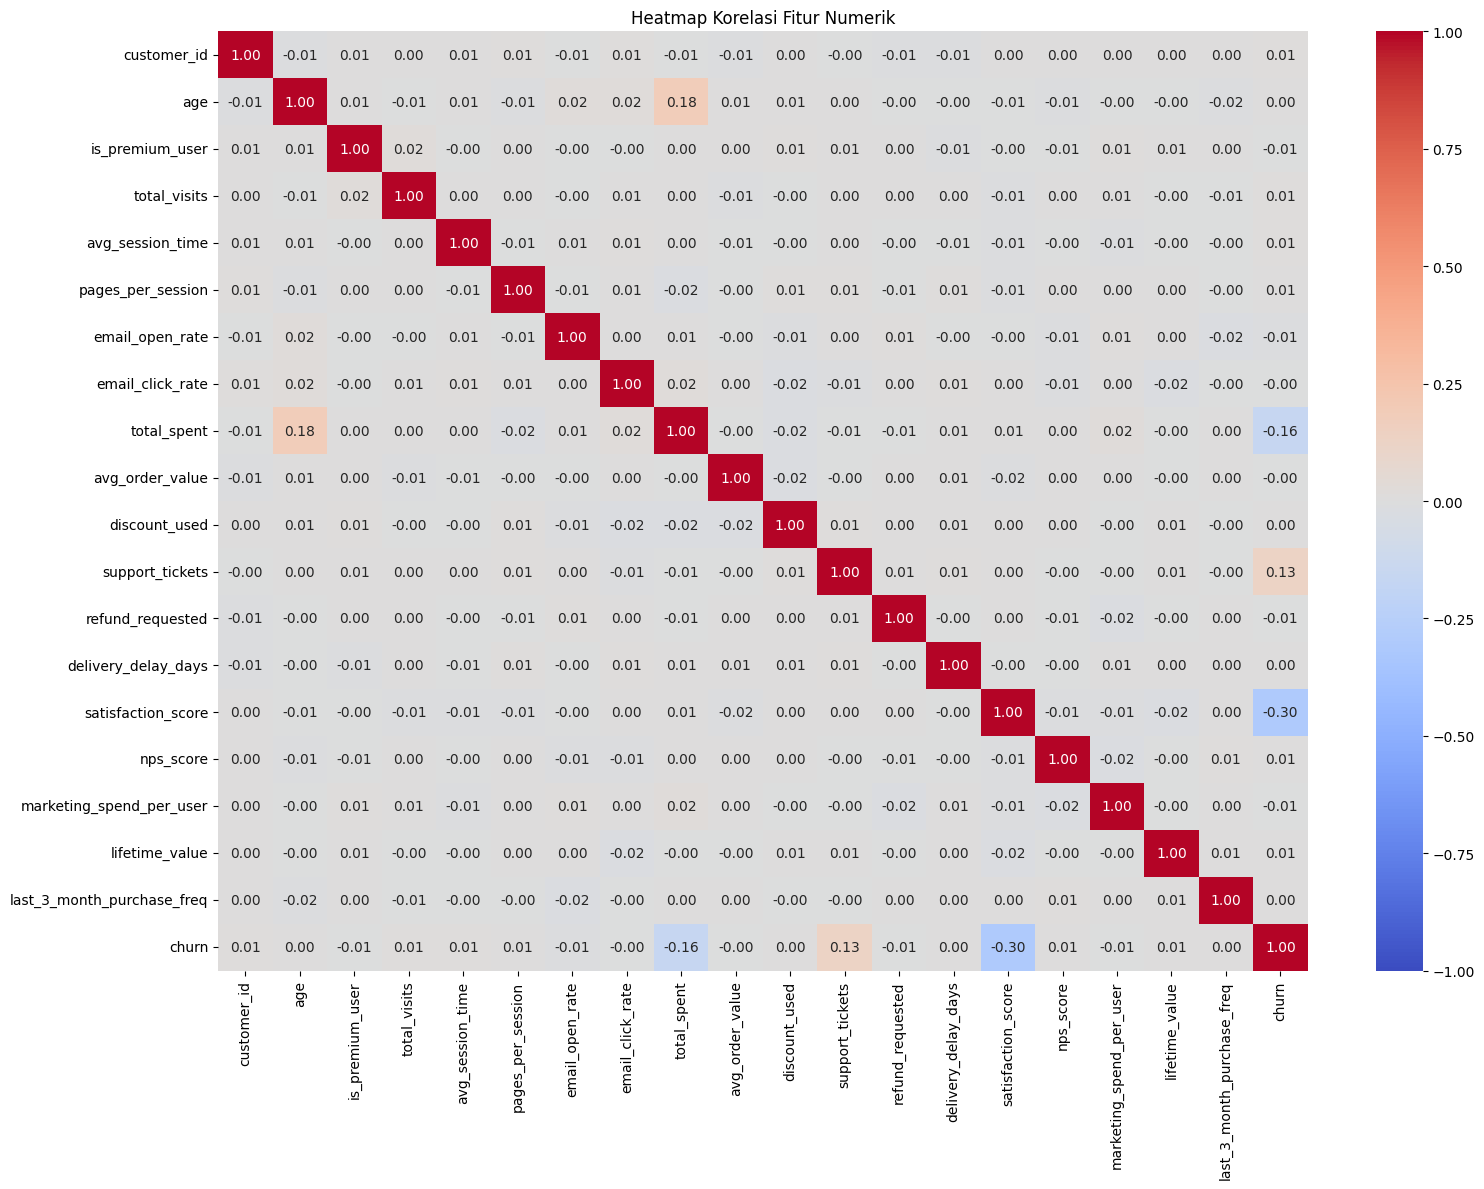

In [5]:
# 7. Heatmap Korelasi
print("\n=== Heatmap Korelasi Fitur Numerik ===")
plt.figure(figsize=(16, 12))
numerical_df = df.select_dtypes(include=['number'])
correlation_matrix = numerical_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Heatmap Korelasi Fitur Numerik')
plt.tight_layout()
plt.show()

# Direct Modeling Baseline
Sengaja  melakukan *modeling* awal menggunakan data kotor dan membuang baris kosong untuk melihat seberapa buruk performa model dasar (Baseline) sebelum masuk tahap *Preprocessing*.

=== HASIL DIRECT MODELING (BASELINE TANPA PREPROCESSING) ===

--- Logistic Regression ---
Accuracy : 0.8424 | Precision: 0.5133 | Recall: 0.1491 | F1: 0.2311


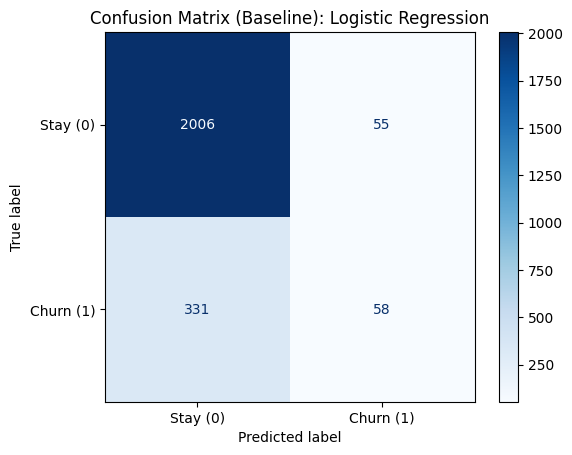


--- Random Forest ---
Accuracy : 0.8376 | Precision: 0.4863 | Recall: 0.4113 | F1: 0.4457


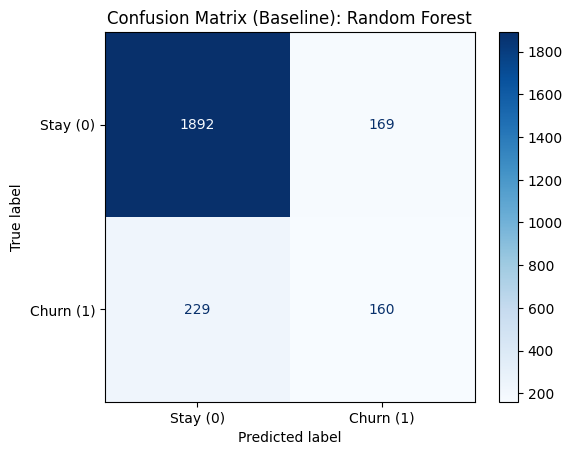


--- Voting Classifier (SVM + KNN) ---
Accuracy : 0.8412 | Precision: 0.0000 | Recall: 0.0000 | F1: 0.0000


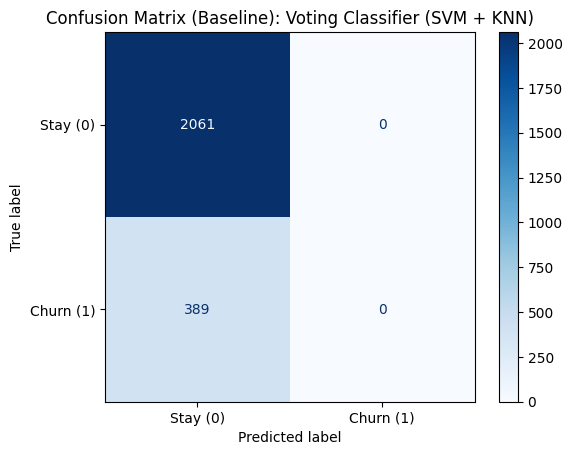

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# Hanya gunakan numerik
fitur_numerik = df.select_dtypes(include='number').drop(columns=['churn', 'customer_id'], errors='ignore').columns
# Drop semua baris yang ada missing value nya (Cara kasar/kotor)
df_clean_baseline = df.dropna(subset=list(fitur_numerik) + ['churn'])

X_base = df_clean_baseline[fitur_numerik]
y_base = df_clean_baseline['churn']

X_train_base, X_test_base, y_train_base, y_test_base = train_test_split(X_base, y_base, test_size=0.2, random_state=42, stratify=y_base)

# Tiga Model yang akan dipakai sesuai definisi (LR, RF, Voting (SVM & KNN))
model_lr_base = LogisticRegression(max_iter=1000, random_state=42)
model_rf_base = RandomForestClassifier(random_state=42)
model_voting_base = VotingClassifier(
    estimators=[('lr', LogisticRegression(max_iter=1000, random_state=42)), ('svm', SVC(random_state=42)), ('knn', KNeighborsClassifier())],
    voting='hard'
)

models_base = {
    'Logistic Regression': model_lr_base,
    'Random Forest': model_rf_base,
    'Voting Classifier (LR + SVM + KNN)': model_voting_base
}

print("=== HASIL DIRECT MODELING (BASELINE TANPA PREPROCESSING) ===")
for name, model in models_base.items():
    model.fit(X_train_base, y_train_base)
    y_pred = model.predict(X_test_base)
    
    acc = accuracy_score(y_test_base, y_pred)
    prec = precision_score(y_test_base, y_pred, zero_division=0)
    rec = recall_score(y_test_base, y_pred, zero_division=0)
    f1 = f1_score(y_test_base, y_pred, zero_division=0)
    
    print(f"\n--- {name} ---")
    print(f"Accuracy : {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")
    
    cm = confusion_matrix(y_test_base, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stay (0)', 'Churn (1)'])
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix (Baseline): {name}')
    plt.show()

# Pertemuan 3: Data Preprocessing
Tahap pembersihan data secara komprehensif berdasarkan temuan di EDA.

1. Data duplikat berhasil dihapus.
2. Outlier umur negatif berhasil ditangani (diganti median: 35.0).

Umur terendah sesudah preprocessing: 0.0


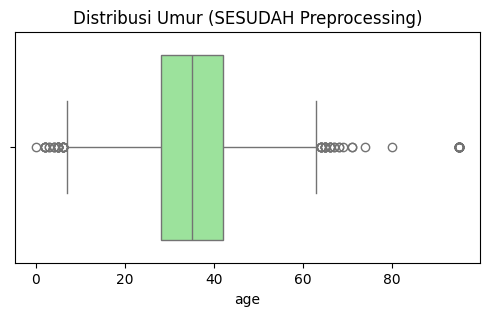

Perhatikan sumbu X pada grafik di atas, nilai negatif sudah tidak ada, outlier telah berhasil diatasi!

3. Fitur ID, Tanggal, dan coupon_code berhasil dibuang.
4. Missing value berhasil ditangani (Imputasi Median untuk Numerik & Modus untuk Kategori).
5. Proses One-Hot Encoding selesai.
Total Kolom Setelah Preprocessing: 42


In [8]:
df_prep = df.copy()

# 1. Penanganan Duplikasi
df_prep = df_prep.drop_duplicates()
print("1. Data duplikat berhasil dihapus.")

# 2. Penanganan Outlier (Ganti umur negatif dengan Median)
median_age = df_prep['age'].median()
df_prep.loc[df_prep['age'] < 0, 'age'] = median_age
print(f"2. Outlier umur negatif berhasil ditangani (diganti median: {median_age}).")

print(f"\nUmur terendah sesudah preprocessing: {df_prep['age'].min()}")
# Tampilkan Boxplot After
plt.figure(figsize=(6, 3))
sns.boxplot(x=df_prep['age'], color='lightgreen')
plt.title('Distribusi Umur (SESUDAH Preprocessing)')
plt.show()
print("Perhatikan sumbu X pada grafik di atas, nilai negatif sudah tidak ada, outlier telah berhasil diatasi!")

# 3. Menghapus Fitur Tidak Relevan & Leakage
kolom_dibuang = ['customer_id', 'coupon_code', 'signup_date', 'last_purchase_date']
df_prep = df_prep.drop(columns=kolom_dibuang, errors='ignore')
print("\n3. Fitur ID, Tanggal, dan coupon_code berhasil dibuang.")

# 4. Menangani Missing Value
kolom_numerik = df_prep.select_dtypes(include='number').columns
for col in kolom_numerik:
    df_prep[col] = df_prep[col].fillna(df_prep[col].median())

kolom_kategori = df_prep.select_dtypes(include='object').columns
for col in kolom_kategori:
    df_prep[col] = df_prep[col].fillna(df_prep[col].mode()[0])
print("4. Missing value berhasil ditangani (Imputasi Median untuk Numerik & Modus untuk Kategori).")

# 5. One-Hot Encoding
df_prep = pd.get_dummies(df_prep, columns=kolom_kategori, drop_first=True)
print("5. Proses One-Hot Encoding selesai.")
print(f"Total Kolom Setelah Preprocessing: {df_prep.shape[1]}")

# Pertemuan 4: Validasi dan Sampling (SMOTE)
Memisahkan data menjadi set pelatihan dan pengujian, melakukan standarisasi (Scaling), lalu menyeimbangkan distribusi target kelas minoritas menggunakan **SMOTE** beserta visualisasinya.

1. Train-Test Split Selesai.
2. Scaling Fitur (StandardScaler) Selesai.
3. SMOTE Selesai diaplikasikan pada Data Training.


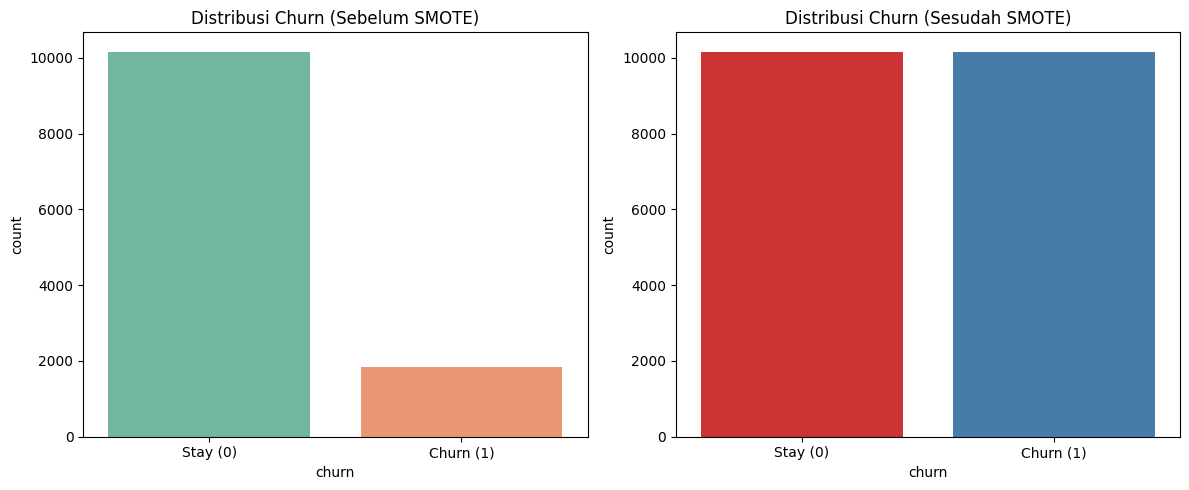

In [9]:
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# 1. Pemisahan Fitur dan Target
X = df_prep.drop(columns=['churn'])
y = df_prep['churn']

# 2. Train-Test Split (80:20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("1. Train-Test Split Selesai.")

# 3. Scaling Fitur (StandardScaler)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("2. Scaling Fitur (StandardScaler) Selesai.")

# 4. SMOTE (Hanya pada Data Training)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)
print("3. SMOTE Selesai diaplikasikan pada Data Training.")

# VISUALISASI SEBELUM & SESUDAH SMOTE
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x=y_train, ax=axes[0], palette='Set2')
axes[0].set_title('Distribusi Churn (Sebelum SMOTE)')
axes[0].set_xticklabels(['Stay (0)', 'Churn (1)'])

sns.countplot(x=y_train_smote, ax=axes[1], palette='Set1')
axes[1].set_title('Distribusi Churn (Sesudah SMOTE)')
axes[1].set_xticklabels(['Stay (0)', 'Churn (1)'])

plt.tight_layout()
plt.show()

### Evaluasi Model Hasil Preprocessing (Tanpa Hyperparameter Tuning)
Sebelum melakukan hyperparameter tuning, mari kita latih dan evaluasi ketiga model tersebut dengan data yang sudah di-preprocess (termasuk hasil SMOTE dan Scaling) menggunakan parameter bawaan (default) sebagai baseline perbandingan yang setara.

In [ ]:
print("=== HASIL MODELING DENGAN PREPROCESSING (TANPA TUNING) ===")
# Inisiasi ulang ketiga model dengan parameter dasar
model_lr_prep = LogisticRegression(max_iter=1000, random_state=42)
model_rf_prep = RandomForestClassifier(random_state=42)
model_voting_prep = VotingClassifier(
    estimators=[('svm', SVC(random_state=42)), ('knn', KNeighborsClassifier())],
    voting='hard'
)

models_prep = {
    'Logistic Regression (Preprocessed)': model_lr_prep,
    'Random Forest (Preprocessed)': model_rf_prep,
    'Voting Classifier (SVM + KNN Preprocessed)': model_voting_prep
}

for name, model in models_prep.items():
    # Latih menggunakan data training hasil SMOTE
    model.fit(X_train_smote, y_train_smote)
    # Prediksi menggunakan data test hasil Scaling (tanpa SMOTE karena SMOTE hanya untuk latih)
    y_pred = model.predict(X_test_scaled)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    
    print(f"\n--- {name} ---")
    print(f"Accuracy : {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")
    
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stay (0)', 'Churn (1)'])
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix: {name}')
    plt.show()


### Skenario 2: Evaluasi Model Hasil Preprocessing (Tanpa Hyperparameter Tuning)
Sebelum melakukan tuning, kita melatih ulang ketiga model dengan **data yang sudah dibersihkan** (hasil pre-processing, scaling, dan SMOTE) menggunakan parameter bawaan (default). Langkah ini memenuhi syarat evaluasi 3 skenario eksperimen.

In [ ]:
print("=== HASIL MODELING DENGAN PREPROCESSING (TANPA TUNING) ===")

# Inisiasi ulang ketiga model dengan parameter dasar
model_lr_prep = LogisticRegression(max_iter=1000, random_state=42)
model_rf_prep = RandomForestClassifier(random_state=42)
model_voting_prep = VotingClassifier(
    estimators=[('lr', LogisticRegression(max_iter=1000, random_state=42)), ('svm', SVC(random_state=42)), ('knn', KNeighborsClassifier())],
    voting='hard'
)

models_prep = {
    'Logistic Regression (Preprocessed)': model_lr_prep,
    'Random Forest (Preprocessed)': model_rf_prep,
    'Voting Classifier (LR + SVM + KNN Preprocessed)': model_voting_prep
}

for name, model in models_prep.items():
    model.fit(X_train_smote, y_train_smote)
    y_pred = model.predict(X_test_scaled)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    
    print(f"\n--- {name} ---")
    print(f"Accuracy : {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")
    
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stay (0)', 'Churn (1)'])
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix (Prep): {name}')
    plt.show()


# Pertemuan 5: Hyperparameter Tuning & Feature Selection
Mencari konfigurasi parameter model yang paling optimal menggunakan **GridSearchCV**.
Sesuai rancangan, kita akan melakukan tuning pada:
1. Logistic Regression (LR)
2. Random Forest (RF)
3. SVM & KNN (untuk digabungkan menjadi Voting Classifier)

In [10]:
from sklearn.model_selection import GridSearchCV

print("\n=== PROSES HYPERPARAMETER TUNING DIMULAI (Dengan Data Bersih + SMOTE) ===")

# 1. Tuning Logistic Regression
logreg_params = {'C': [0.1, 1.0, 10.0], 'solver': ['liblinear']}
logreg_grid = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42), logreg_params, cv=3, scoring='accuracy', n_jobs=-1)
logreg_grid.fit(X_train_smote, y_train_smote)
best_logreg = logreg_grid.best_estimator_
print(f"1. Parameter Terbaik Logistic Regression: {logreg_grid.best_params_}")

# 2. Tuning Random Forest
rf_params = {'n_estimators': [50, 100], 'max_depth': [5, 10]}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=3, scoring='accuracy', n_jobs=-1)
rf_grid.fit(X_train_smote, y_train_smote)
best_rf = rf_grid.best_estimator_
print(f"2. Parameter Terbaik Random Forest: {rf_grid.best_params_}")

# 3. Tuning SVM (Untuk Voting)
svm_params = {'C': [0.1, 1.0], 'kernel': ['rbf']}
svm_grid = GridSearchCV(SVC(probability=True, random_state=42), svm_params, cv=3, scoring='accuracy', n_jobs=-1)
svm_grid.fit(X_train_smote, y_train_smote)
best_svm = svm_grid.best_estimator_
print(f"3. Parameter Terbaik SVM: {svm_grid.best_params_}")

# 4. Tuning KNN (Untuk Voting)
knn_params = {'n_neighbors': [3, 5, 7], 'weights': ['uniform', 'distance']}
knn_grid = GridSearchCV(KNeighborsClassifier(), knn_params, cv=3, scoring='accuracy', n_jobs=-1)
knn_grid.fit(X_train_smote, y_train_smote)
best_knn = knn_grid.best_estimator_
print(f"4. Parameter Terbaik KNN: {knn_grid.best_params_}")

# 5. Gabung ke Voting Classifier (Hanya SVM & KNN)
voting_clf_tuned = VotingClassifier(
    estimators=[('lr', best_logreg), ('svm', best_svm), ('knn', best_knn)],
    voting='soft'
)
voting_clf_tuned.fit(X_train_smote, y_train_smote)
print("\n5. Model Ensemble (Voting Classifier LR+SVM+KNN) Selesai Dilatih.")


=== PROSES HYPERPARAMETER TUNING DIMULAI (Dengan Data Bersih + SMOTE) ===
1. Parameter Terbaik Logistic Regression: {'C': 10.0, 'solver': 'liblinear'}
2. Parameter Terbaik Random Forest: {'max_depth': 10, 'n_estimators': 50}
3. Parameter Terbaik SVM: {'C': 1.0, 'kernel': 'rbf'}
4. Parameter Terbaik KNN: {'n_neighbors': 3, 'weights': 'distance'}

5. Model Ensemble (Voting Classifier SVM+KNN) Selesai Dilatih.


=== HASIL EVALUASI AKHIR (HYPERPARAMETER TUNING & SMOTE) ===

--- Logistic Regression (Tuned) ---
Accuracy : 0.7587 | Precision: 0.3593 | Recall: 0.7326 | F1: 0.4821


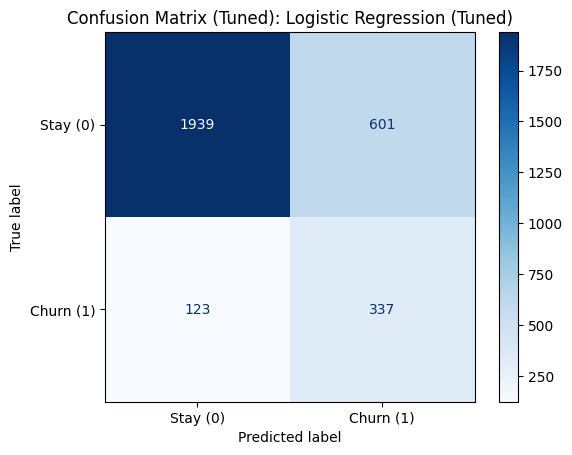


--- Random Forest (Tuned) ---
Accuracy : 0.8540 | Precision: 0.5150 | Recall: 0.8217 | F1: 0.6332


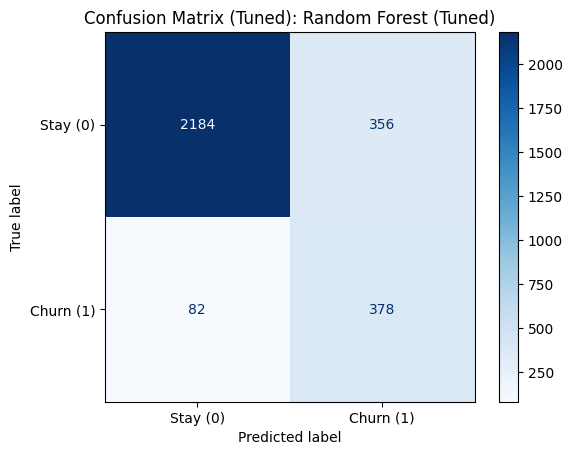


--- Voting Classifier (SVM+KNN Tuned) ---
Accuracy : 0.7457 | Precision: 0.2977 | Recall: 0.4848 | F1: 0.3689


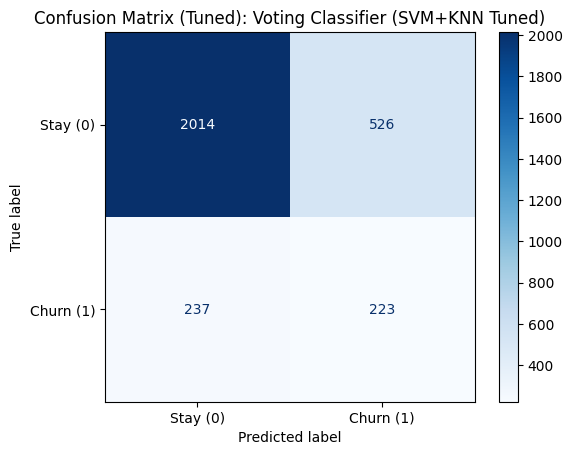


🌟 MODEL TERBAIK ADALAH: Random Forest (Tuned) dengan Akurasi: 0.8540


In [11]:
print("=== HASIL EVALUASI AKHIR (HYPERPARAMETER TUNING & SMOTE) ===")
# Tiga Model Sesuai Permintaan: LR, RF, Voting(SVM+KNN)
models_tuned = {
    "Logistic Regression (Tuned)": best_logreg,
    "Random Forest (Tuned)": best_rf,
    "Voting Classifier (LR+SVM+KNN Tuned)": voting_clf_tuned
}

best_model_name = ""
best_model_score = 0
best_model_object = None

for name, model in models_tuned.items():
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    print(f"\n--- {name} ---")
    print(f"Accuracy : {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")
    
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stay (0)', 'Churn (1)'])
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix (Tuned): {name}')
    plt.show()
    
    if acc > best_model_score:
        best_model_score = acc
        best_model_name = name
        best_model_object = model

print(f"\n🌟 MODEL TERBAIK ADALAH: {best_model_name} dengan Akurasi: {best_model_score:.4f}")


=== Analisis Feature Importance (Khusus Random Forest Tuned) ===


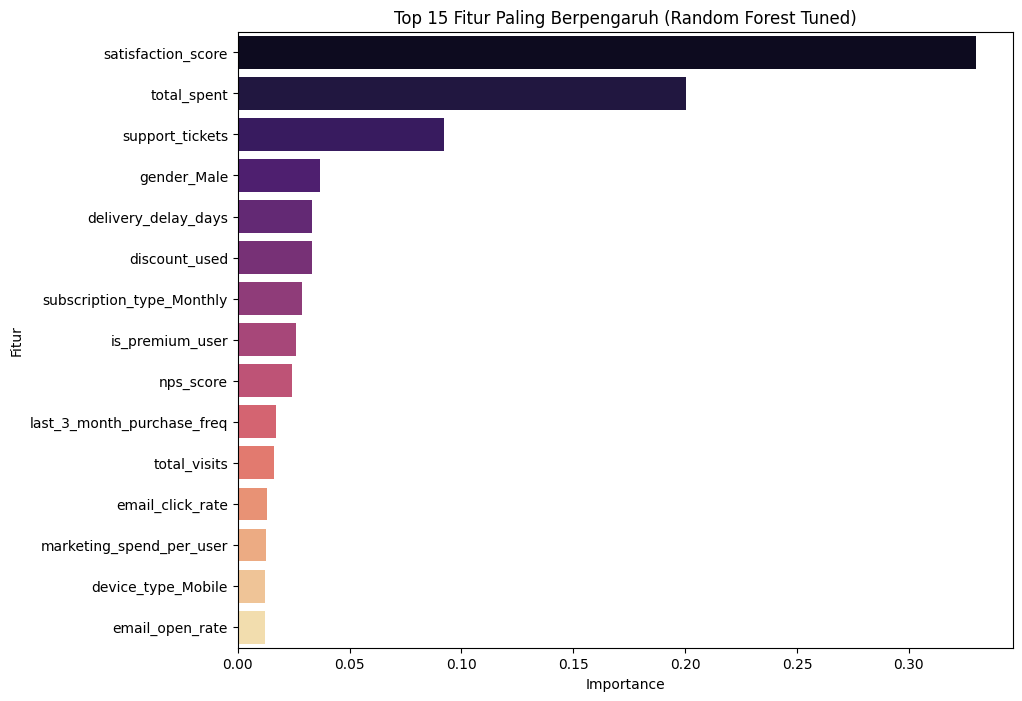

In [12]:
print("\n=== Analisis Feature Importance (Khusus Random Forest Tuned) ===")
importances_tuned = best_rf.feature_importances_
fi_tuned_df = pd.DataFrame({'Fitur': X.columns, 'Importance': importances_tuned}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Fitur', data=fi_tuned_df.head(15), palette='magma')
plt.title('Top 15 Fitur Paling Berpengaruh (Random Forest Tuned)')
plt.show()

# Ekspor Model & Simulasi Testing Akhir
Kode di bawah akan secara dinamis mengekspor model dengan performa tertinggi ke dalam format `.joblib`. Kemudian, kita akan menguji model tersebut dengan memasukkan satu baris sampel data *asli* dari dataset kita (Data row ke-0) untuk membuktikan bahwa model mampu mencerna dataset mentah dan menghasilkan prediksi secara akurat.

In [13]:
import joblib

# 1. Simpan Model Terbaik, Scaler, dan Daftar Fitur Asli
model_filename = 'churn_model.joblib'
joblib.dump(best_model_object, model_filename)
joblib.dump(scaler, 'scaler.joblib')
joblib.dump(list(X.columns), 'model_features.joblib')

print(f"Model '{best_model_name}' berhasil diekspor sebagai '{model_filename}'")

Model 'Random Forest (Tuned)' berhasil diekspor sebagai 'churn_model.joblib'


In [14]:
# 2. Simulasi Testing Mengambil Langsung Dari Dataset Asli (Mirip Persis!)
print("\n=== SIMULASI TESTING MODEL PADA SAMPEL ASLI ===")

# Mengambil baris PERTAMA (index 0) dari raw dataset `df` sebagai sampel pengujian
# Kita drop kolom churn karena churn adalah jawaban yang ingin ditebak
sample_data = df.drop(columns=['churn']).iloc[0].to_dict()
actual_churn_status = df['churn'].iloc[0]

# Tampilkan sample datanya 
print("Data Pelanggan (Baris 0 dari CSV):")
print(sample_data)
print(f"\nStatus ASLI di CSV: {'Churn (1)' if actual_churn_status == 1 else 'Stay (0)'}")

# Proses simulasi pipeline seperti yang dialami model
df_sample = pd.DataFrame([sample_data])
expected_features = joblib.load('model_features.joblib')

# Buat dataframe kosong (One-hot encoded blueprint)
df_sample_encoded = pd.DataFrame(0.0, index=[0], columns=expected_features)

for col in df_sample.select_dtypes(include='number').columns:
    if col in expected_features:
        df_sample_encoded.at[0, col] = df_sample.at[0, col]

for col in df_sample.select_dtypes(include='object').columns:
    val = df_sample.at[0, col]
    dummy_col = f"{col}_{val}"
    if dummy_col in expected_features:
        df_sample_encoded.at[0, dummy_col] = 1

# Panggil file joblib yang telah disave
loaded_model = joblib.load(model_filename)
loaded_scaler = joblib.load('scaler.joblib')

# Scale lalu prediksi
sample_scaled = loaded_scaler.transform(df_sample_encoded)
prediksi = loaded_model.predict(sample_scaled)[0]
probabilitas = loaded_model.predict_proba(sample_scaled)[0]

status = 'Churn (Berhenti)' if prediksi == 1 else 'Stay (Bertahan)'
print(f"\n=> Prediksi Sistem (Model): {status}")
print(f"=> Probabilitas Churn: {probabilitas[1]*100:.2f}%")

if prediksi == actual_churn_status:
    print("✅ PREDIKSI BENAR! Model berhasil menebak persis seperti di dataset.")
else:
    print("❌ Prediksi Meleset.")


=== SIMULASI TESTING MODEL PADA SAMPEL ASLI ===
Data Pelanggan (Baris 0 dari CSV):
{'customer_id': 10001, 'gender': 'Male', 'age': 52.0, 'country': 'India', 'city': 'Berlin', 'signup_date': '2022-05-10 00:00:00', 'last_purchase_date': '2024-12-31 00:00:00', 'acquisition_channel': 'Email', 'device_type': 'Tablet', 'subscription_type': 'Annual', 'is_premium_user': 1, 'total_visits': 7, 'avg_session_time': 13.9037447368063, 'pages_per_session': 5.41516421012665, 'email_open_rate': 0.67, 'email_click_rate': 0.26, 'total_spent': 559.524958294943, 'avg_order_value': 65.2467036526621, 'discount_used': 0, 'coupon_code': 'NEW20', 'support_tickets': 0, 'refund_requested': 0, 'delivery_delay_days': 3, 'payment_method': 'UPI', 'satisfaction_score': 3.0, 'nps_score': 10, 'marketing_spend_per_user': 27.56, 'lifetime_value': 915.310826609752, 'last_3_month_purchase_freq': 14}

Status ASLI di CSV: Stay (0)

=> Prediksi Sistem (Model): Stay (Bertahan)
=> Probabilitas Churn: 8.70%
✅ PREDIKSI BENAR! Mod